In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

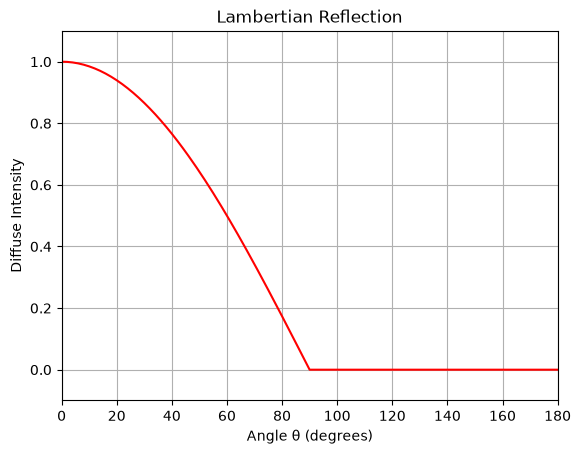

In [2]:
# 램버트 구현

# 각도 0° ~ 180°
theta = np.linspace(0, 180, 181)

# 각도 -> 라디안
radian = np.radians(theta)

# 램버트 반사
lambert = np.cos(radian)

# 음수는 0으로 제한
lambert = np.maximum(lambert, 0)

# 그래프
plt.plot(theta, lambert, "r")

plt.title("Lambertian Reflection")
plt.xlabel("Angle θ (degrees)")
plt.ylabel("Diffuse Intensity")

plt.xlim(0, 180)
plt.ylim(-0.1, 1.1)

plt.grid()

plt.show()

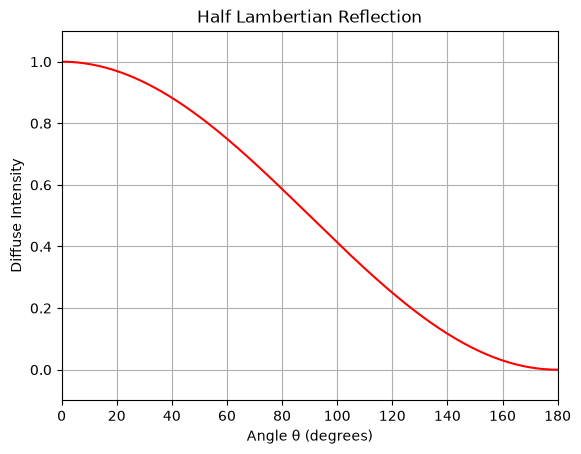

In [3]:
# 하프 램버트
radian = np.radians(theta)
lambert = np.cos(radian)

halfLambert = (0.5*lambert) + 0.5

# 그래프
plt.plot(theta, halfLambert, "r")

plt.title("Half Lambertian Reflection")
plt.xlabel("Angle θ (degrees)")
plt.ylabel("Diffuse Intensity")

plt.xlim(0, 180)
plt.ylim(-0.1, 1.1)

plt.grid()

plt.show()

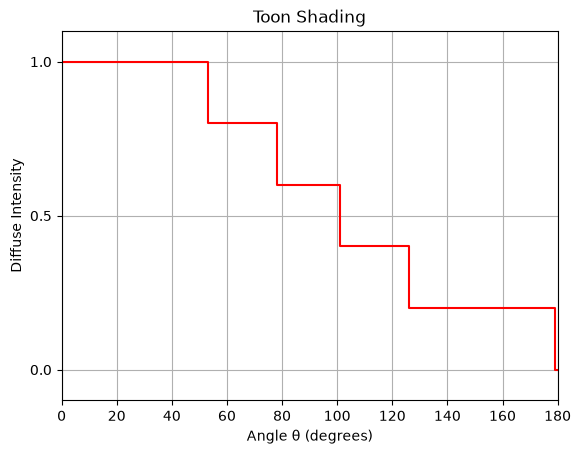

In [4]:
# 툰셰이딩
toon = np.ceil(halfLambert * 5) / 5 # n의 값으로 툰셰이딩 단계 조정

# 그래프
plt.step(theta, toon, "r")

plt.title("Toon Shading")
plt.xlabel("Angle θ (degrees)")
plt.ylabel("Diffuse Intensity")

plt.xlim(0, 180)
plt.ylim(-0.1, 1.1)

plt.yticks([0, 0.5, 1.0])

plt.grid()

plt.show()

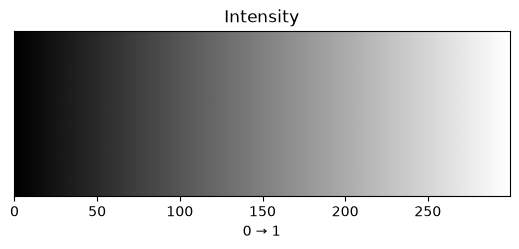

In [5]:
# Intensity : 0 ~ 1
I = np.linspace(0, 1, 300)

gradient = np.tile(I, (100, 1))

plt.imshow(
    gradient,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title("Intensity")
plt.xlabel("0 → 1")
plt.yticks([])

plt.show()

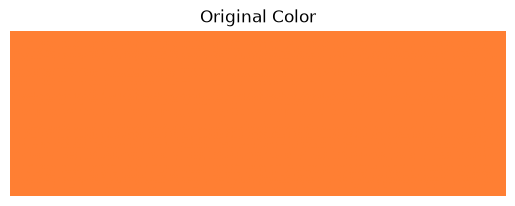

In [6]:
# 원본 색상 RGB
C = np.array([1.0, 0.5, 0.2])

# 단색 이미지 생성
color_image = np.ones((100, 300, 3)) * C

plt.imshow(color_image)
plt.title("Original Color")
plt.axis("off")

plt.show()

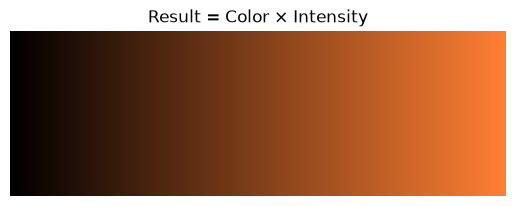

In [7]:
# RGB 이미지에 Intensity 적용
result = color_image * gradient[:, :, None]

plt.imshow(result)
plt.title("Result = Color × Intensity")
plt.axis("off")

plt.show()

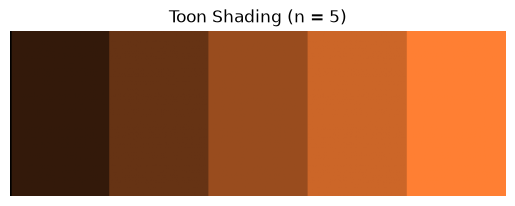

In [8]:
# Toon Shading
n = 5

toon_gradient = np.ceil(gradient * n) / n
toon_result = color_image * toon_gradient[:, :, None]

plt.imshow(toon_result)
plt.title("Toon Shading (n = 5)")
plt.axis("off")
plt.show()

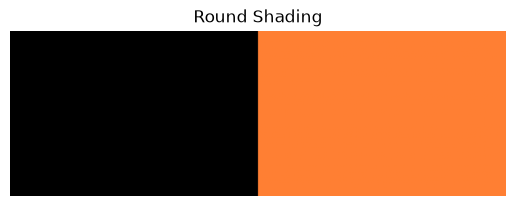

In [9]:
# Round
round_gradient = np.round(gradient)
round_result = color_image * round_gradient[:, :, None]

plt.imshow(round_result)
plt.title("Round Shading")
plt.axis("off")
plt.show()

In [10]:
# A 색상
color_A = np.ones((height, 300, 3)) * A

plt.imshow(color_A)
plt.title("Color A (Shadow Color)")
plt.axis("off")
plt.show()

NameError: name 'height' is not defined

In [ ]:
# B 색상
color_B = np.ones((height, 300, 3)) * B

plt.imshow(color_B)
plt.title("Color B (Light Color)")
plt.axis("off")
plt.show()

In [ ]:
alpha_gradient = np.tile(alpha, (height, 1))

plt.imshow(
    alpha_gradient,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title("Interpolation Factor (α)")
plt.xlabel("0 → 1")
plt.yticks([])
plt.show()

In [ ]:
# (100, 300) → (100, 300, 1)
alpha_3d = alpha_gradient[:, :, None]

# Lerp(A, B, alpha)
result = (1 - alpha_3d) * A + alpha_3d * B

plt.imshow(result)
plt.title("Lerp(A, B, t)")
plt.xlabel("A  →  B")
plt.yticks([])
plt.show()

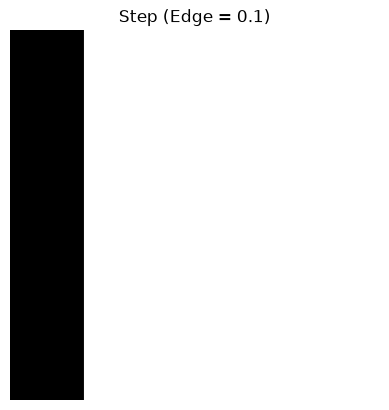

In [24]:
size = 300

I = np.linspace(0, 1, size)
gradient = np.tile(I, (size, 1))

# step(edge, x)
edge = 0.2

step_result = np.where(gradient < edge, 0.0, 1.0)

plt.imshow(step_result, cmap="gray", vmin=0, vmax=1)
plt.title("Step (Edge = 0.1)")
plt.axis("off")
plt.show()

In [1]:
edge0 = 0.2
edge1 = 0.3

t = np.clip(
    (gradient - edge0) / (edge1 - edge0),
    0,
    1
)

smoothstep_result = t * t * (3 - 2 * t)

plt.imshow(smoothstep_result, cmap="gray", vmin=0, vmax=1)
plt.title("Smoothstep (0.1, 0.2)")
plt.axis("off")
plt.show()

NameError: name 'np' is not defined

In [1]:
# Ramp 색상
colors = [
    (0.1, 0.1, 0.2),   # 어두운 색
    (0.3, 0.2, 0.5),   # 중간 색
    (0.8, 0.5, 0.2),   # 밝은 색
    (1.0, 0.9, 0.5)
]

cmap = LinearSegmentedColormap.from_list("toonRamp", colors)

ramp = np.linspace(0, 1, 500).reshape(1, -1)

value = 0.65

plt.figure(figsize=(10, 2))

plt.imshow(
    ramp,
    aspect='auto',
    cmap=cmap,
    extent=[0, 1, 0, 1]
)

plt.xlabel("Half-Lambert Value → Ramp Texture U")
plt.yticks([])
plt.xlim(0, 1)

plt.show()

NameError: name 'LinearSegmentedColormap' is not defined

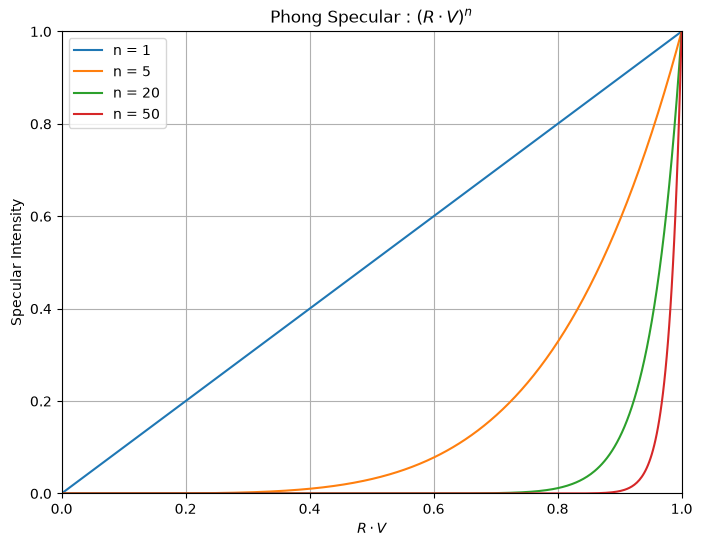

In [7]:
#Phong Specular 지수 n에 따른 정반사 강도 변화

# R·V 값
x = np.linspace(0, 1, 500)

# Shininess 값
n_values = [1, 5, 20, 50]

plt.figure(figsize=(8, 6))

for n in n_values:
    specular = x ** n
    plt.plot(x, specular, label=f'n = {n}')

plt.xlabel(r'$R \cdot V$')
plt.ylabel('Specular Intensity')

plt.title(r'Phong Specular : $(R \cdot V)^n$')

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.grid()
plt.legend()

plt.show()

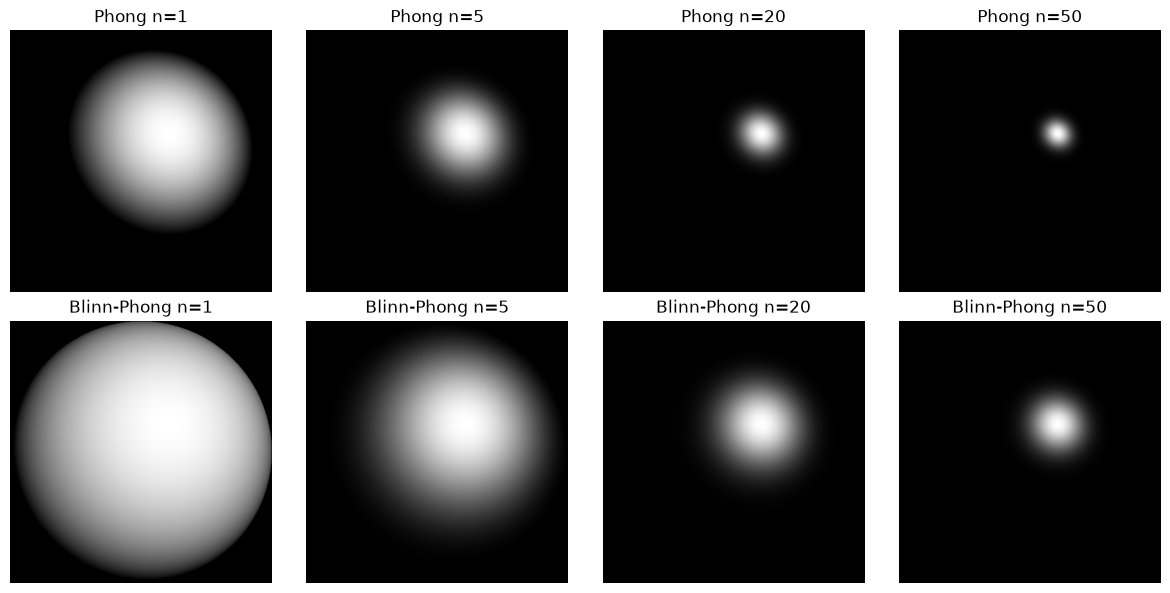

In [26]:
n_values = [1, 5, 20, 50]

size = 500
x = np.linspace(-1, 1, size)
y = np.linspace(-1, 1, size)
X, Y = np.meshgrid(x, y)

# 구 형태
Z2 = 1 - X**2 - Y**2
mask = Z2 >= 0

Z = np.zeros_like(X)
Z[mask] = np.sqrt(Z2[mask])

# 표면 Normal
N = np.stack([X, Y, Z], axis=-1)

# Light Vector
L = np.array([0.5, 0.5, 1.0])
L = L / np.linalg.norm(L)

# View Vector
V = np.array([0.0, 0.0, 1.0])

# -----------------------
# Phong
# -----------------------

NL = np.sum(N * L, axis=-1)

# R = 2(N·L)N - L
R = 2 * NL[..., None] * N - L

RV = np.sum(R * V, axis=-1)
RV = np.maximum(0, RV)

# -----------------------
# Blinn-Phong
# -----------------------

H = L + V
H = H / np.linalg.norm(H)

NH = np.sum(N * H, axis=-1)
NH = np.maximum(0, NH)

# -----------------------
# 그래프
# -----------------------

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, n in enumerate(n_values):

    phong = RV ** n
    blinn = NH ** n

    phong[~mask] = 0
    blinn[~mask] = 0

    axes[0, i].imshow(
        phong,
        cmap='gray',
        vmin=0,
        vmax=1,
        origin='lower'
    )

    axes[0, i].set_title(f"Phong n={n}")
    axes[0, i].axis('off')

    axes[1, i].imshow(
        blinn,
        cmap='gray',
        vmin=0,
        vmax=1,
        origin='lower'
    )

    axes[1, i].set_title(f"Blinn-Phong n={n}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [1]:
# ==================================
# 구 표면 생성
# ==================================

size = 500

x = np.linspace(-1, 1, size)
y = np.linspace(-1, 1, size)
X, Y = np.meshgrid(x, y)

# 단위 구 x² + y² + z² = 1
R2 = X**2 + Y**2
mask = R2 <= 1

Z = np.zeros_like(X)
Z[mask] = np.sqrt(1 - R2[mask])


# ==================================
# 1. N · V
# ==================================

# 카메라가 정면에서 바라본다고 가정
# V = (0, 0, 1)
# 따라서 N · V = Nz = Z

NdotV = np.clip(Z, 0, 1)


# ==================================
# 2. 1 - N · V
# ==================================

inverse = 1 - NdotV


# ==================================
# 3. (1 - N · V)^2
# ==================================

fresnel = inverse ** 2


# ==================================
# 원 밖 영역 제거
# ==================================

images = [
    NdotV.copy(),
    inverse.copy(),
    fresnel.copy()
]

for image in images:
    image[~mask] = np.nan


# ==================================
# 시각화
# ==================================

cmap = plt.cm.gray.copy()

# 구 바깥쪽을 회색으로 표시
cmap.set_bad('#555555')

titles = [
    r'$N \cdot V$',
    r'$1 - (N \cdot V)$',
    r'$(1 - N \cdot V)^2$'
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4),
    facecolor='#555555'
)

for ax, image, title in zip(axes, images, titles):

    ax.imshow(
        image,
        extent=[-1, 1, -1, 1],
        origin='lower',
        cmap=cmap,
        vmin=0,
        vmax=1
    )

    ax.set_title(
        title,
        fontsize=16,
        color='white'
    )

    ax.set_facecolor('#555555')
    ax.set_aspect('equal')
    ax.axis('off')

plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import distance_transform_edt

# 그림자 마스크 불러오기
img = Image.open("face_shadow_mask.png").convert("L")
mask = np.array(img) > 127

# 경계 안/밖까지의 거리
distance_inside = distance_transform_edt(mask)
distance_outside = distance_transform_edt(~mask)

# Signed Distance
sdf = distance_inside - distance_outside

# 0~1 범위로 변환
spread = 50.0
sdf = np.clip(0.5 + sdf / (2 * spread), 0, 1)

# 저장
Image.fromarray((sdf * 255).astype(np.uint8)).save("Face_SDF.png")

plt.figure(figsize=(6, 6))
plt.imshow(sdf, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'face_shadow_mask.png'